In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import json
from ast import literal_eval
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

In [ ]:
pip install seaborn
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [10]:
df_train = pd.read_csv('../../Dataset/pii_dataset.csv', converters={
        'tokens': literal_eval, 
        'labels': literal_eval, 
        'trailing_whitespace': literal_eval
    })
df_train.rename(columns={'text': 'full_text'}, inplace=True)
df_train.head()

,document,full_text,tokens,trailing_whitespace,labels,prompt,prompt_id,name,email,phone,job,address,username,url,hobby,len
0,1073d46f-2241-459b-ab01-851be8d26436,,"[My, name, is, Aaliyah, Popova,, and, I, am, a...","[True, True, True, True, True, True, True, Tru...","[O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O...",\n Aaliyah Popova is a jeweler with 13 year...,1,Aaliyah Popova,aaliyah.popova4783@aol.edu,(95) 94215-7906,jeweler,97 Lincoln Street,NaN,NaN,Podcasting,363
1,5ec717a9-17ee-48cd-9d76-30ae256c9354,"My name is Konstantin Becker, and I'm a develo...","[My, name, is, Konstantin, Becker,, and, I'm, ...","[True, True, True, True, True, True, True, Tru...","[O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O...",\n Konstantin Becker is a developer with 2 ...,1,Konstantin Becker,konstantin.becker@gmail.com,0475 4429797,developer,826 Webster Street,NaN,NaN,Quilting,255
2,353da41e-7799-4071-ab20-d959b362612e,"As Mieko Mitsubishi, an account manager at a p...","[As, Mieko, Mitsubishi,, an, account, manager,...","[True, True, True, True, True, True, True, Tru...","[O, B-NAME_STUDENT, I-NAME_STUDENT, O, O, O, O...",\n Mieko Mitsubishi is a account manager. W...,3,Mieko Mitsubishi,mieko_mitsubishi@msn.org,+27 61 222 4762,account manager,1309 Southwest 71st Terrace,NaN,NaN,Metal detecting,259
3,9324ee01-7bdc-41b1-a7a5-01307f72c20d,"My name is Kazuo Sun, and I'm an air traffic c...","[My, name, is, Kazuo, Sun,, and, I'm, an, air,...","[True, True, True, True, True, True, True, Tru...","[O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O...",\n Kazuo Sun is a air traffic controller wi...,1,Kazuo Sun,kazuosun@hotmail.net,0304 2215930,air traffic controller,736 Sicard Street Southeast,NaN,NaN,Amateur radio,281
4,971fe266-2739-4f1b-979b-7f64e07d5a4a,"My name is Arina Sun, and I'm a dental hygieni...","[My, name, is, Arina, Sun,, and, I'm, a, denta...","[True, True, True, True, True, True, True, Tru...","[O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O...",\n Arina Sun is a dental hygienist. Write a...,3,Arina Sun,arina-sun@gmail.net,0412 1245924,dental hygienist,5701 North 67th Avenue,NaN,NaN,Related,210


In [11]:
print(df_train.shape, df_train_external.shape)

(4434, 16) (4434, 16)


In [12]:

df_train["tokens_length"] = df_train["tokens"].apply(len)

In [ ]:
df_train["labels"]  

0       [O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O...
1       [O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O...
2       [O, B-NAME_STUDENT, I-NAME_STUDENT, O, O, O, O...
3       [O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O...
4       [O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O...
                              ...                        
4429    [O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O, O...
4430    [O, O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O...
4431    [O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O...
4432    [O, B-NAME_STUDENT, I-NAME_STUDENT, O, O, O, O...
4433    [O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O, O...
Name: labels, Length: 4434, dtype: object

In [14]:
uniq_labels = set()
for labels in df_train["labels"]:
    uniq_labels.update(labels)
    
list(uniq_labels)

['I-STREET_ADDRESS',
 'O',
 'B-NAME_STUDENT',
 'B-STREET_ADDRESS',
 'B-EMAIL',
 'B-USERNAME',
 'B-PHONE_NUM',
 'B-URL_PERSONAL',
 'I-NAME_STUDENT',
 'I-PHONE_NUM']

In [15]:
def count_vectorize(labels):
    counts = {uniq_label: 0 for uniq_label in uniq_labels}
    for label in labels:
        counts[label] += 1
    counts['total'] = len(labels)
    counts['total_pii'] = len(labels) - counts['O']
    counts['total_not_pii'] = counts['O']
    return counts

df_train_labels_count_vect = pd.DataFrame.from_records(df_train["labels"].apply(count_vectorize))
df_train = pd.concat([df_train, df_train_labels_count_vect], axis=1)

In [16]:
df_train.head()

,document,full_text,tokens,trailing_whitespace,labels,prompt,prompt_id,name,email,phone,...,B-STREET_ADDRESS,B-EMAIL,B-USERNAME,B-PHONE_NUM,B-URL_PERSONAL,I-NAME_STUDENT,I-PHONE_NUM,total,total_pii,total_not_pii
0,1073d46f-2241-459b-ab01-851be8d26436,,"[My, name, is, Aaliyah, Popova,, and, I, am, a...","[True, True, True, True, True, True, True, Tru...","[O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O...",\n Aaliyah Popova is a jeweler with 13 year...,1,Aaliyah Popova,aaliyah.popova4783@aol.edu,(95) 94215-7906,...,1,1,0,1,0,1,1,363,8,355
1,5ec717a9-17ee-48cd-9d76-30ae256c9354,"My name is Konstantin Becker, and I'm a develo...","[My, name, is, Konstantin, Becker,, and, I'm, ...","[True, True, True, True, True, True, True, Tru...","[O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O...",\n Konstantin Becker is a developer with 2 ...,1,Konstantin Becker,konstantin.becker@gmail.com,0475 4429797,...,1,1,0,1,0,1,1,255,8,247
2,353da41e-7799-4071-ab20-d959b362612e,"As Mieko Mitsubishi, an account manager at a p...","[As, Mieko, Mitsubishi,, an, account, manager,...","[True, True, True, True, True, True, True, Tru...","[O, B-NAME_STUDENT, I-NAME_STUDENT, O, O, O, O...",\n Mieko Mitsubishi is a account manager. W...,3,Mieko Mitsubishi,mieko_mitsubishi@msn.org,+27 61 222 4762,...,1,1,0,0,0,2,0,259,9,250
3,9324ee01-7bdc-41b1-a7a5-01307f72c20d,"My name is Kazuo Sun, and I'm an air traffic c...","[My, name, is, Kazuo, Sun,, and, I'm, an, air,...","[True, True, True, True, True, True, True, Tru...","[O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O...",\n Kazuo Sun is a air traffic controller wi...,1,Kazuo Sun,kazuosun@hotmail.net,0304 2215930,...,1,1,0,1,0,1,1,281,9,272
4,971fe266-2739-4f1b-979b-7f64e07d5a4a,"My name is Arina Sun, and I'm a dental hygieni...","[My, name, is, Arina, Sun,, and, I'm, a, denta...","[True, True, True, True, True, True, True, Tru...","[O, O, O, B-NAME_STUDENT, I-NAME_STUDENT, O, O...",\n Arina Sun is a dental hygienist. Write a...,3,Arina Sun,arina-sun@gmail.net,0412 1245924,...,1,1,0,0,0,1,0,210,7,203


Aggregate Label Counts

In [17]:
recs = []
for uniq_label in uniq_labels:
    recs.append({
        'label': uniq_label,
        'count': df_train[uniq_label].sum()
    })
recs_df = pd.DataFrame.from_records(recs)

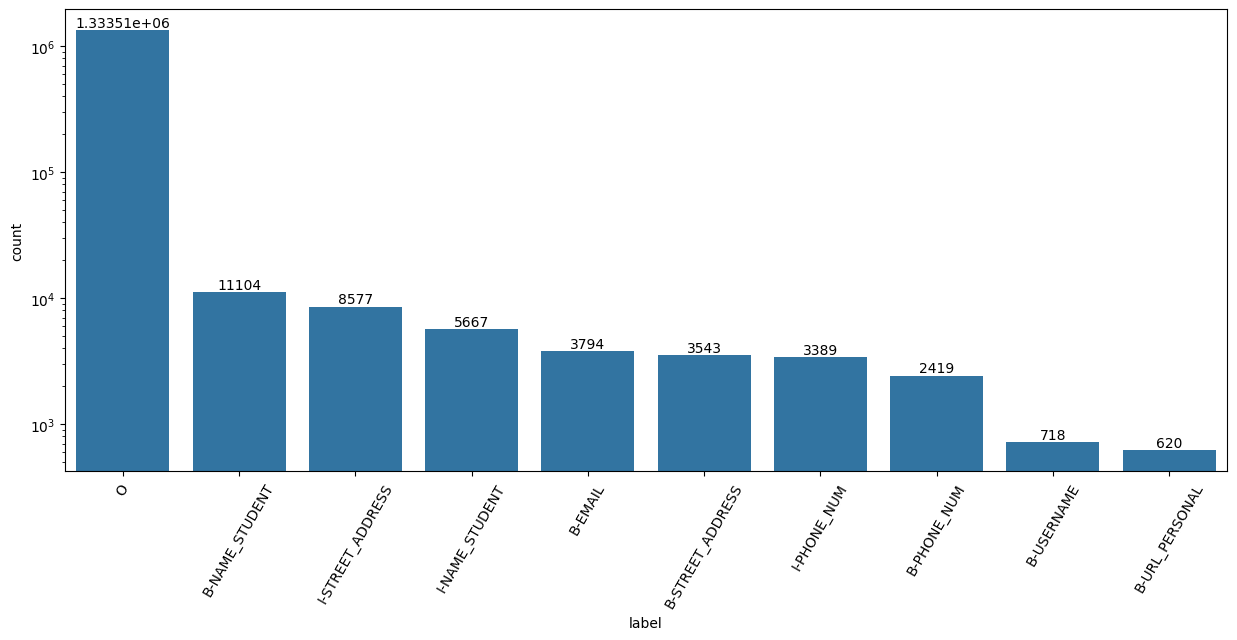

In [18]:
plt.figure(figsize=(15, 6))
plt.xticks(rotation=60)

ax = sns.barplot(data = recs_df.sort_values(by='count', ascending=False),
                 x = 'label', y = 'count')
ax.bar_label(ax.containers[0])
ax.set_yscale('log')

plt.show()

Individual Label Counts

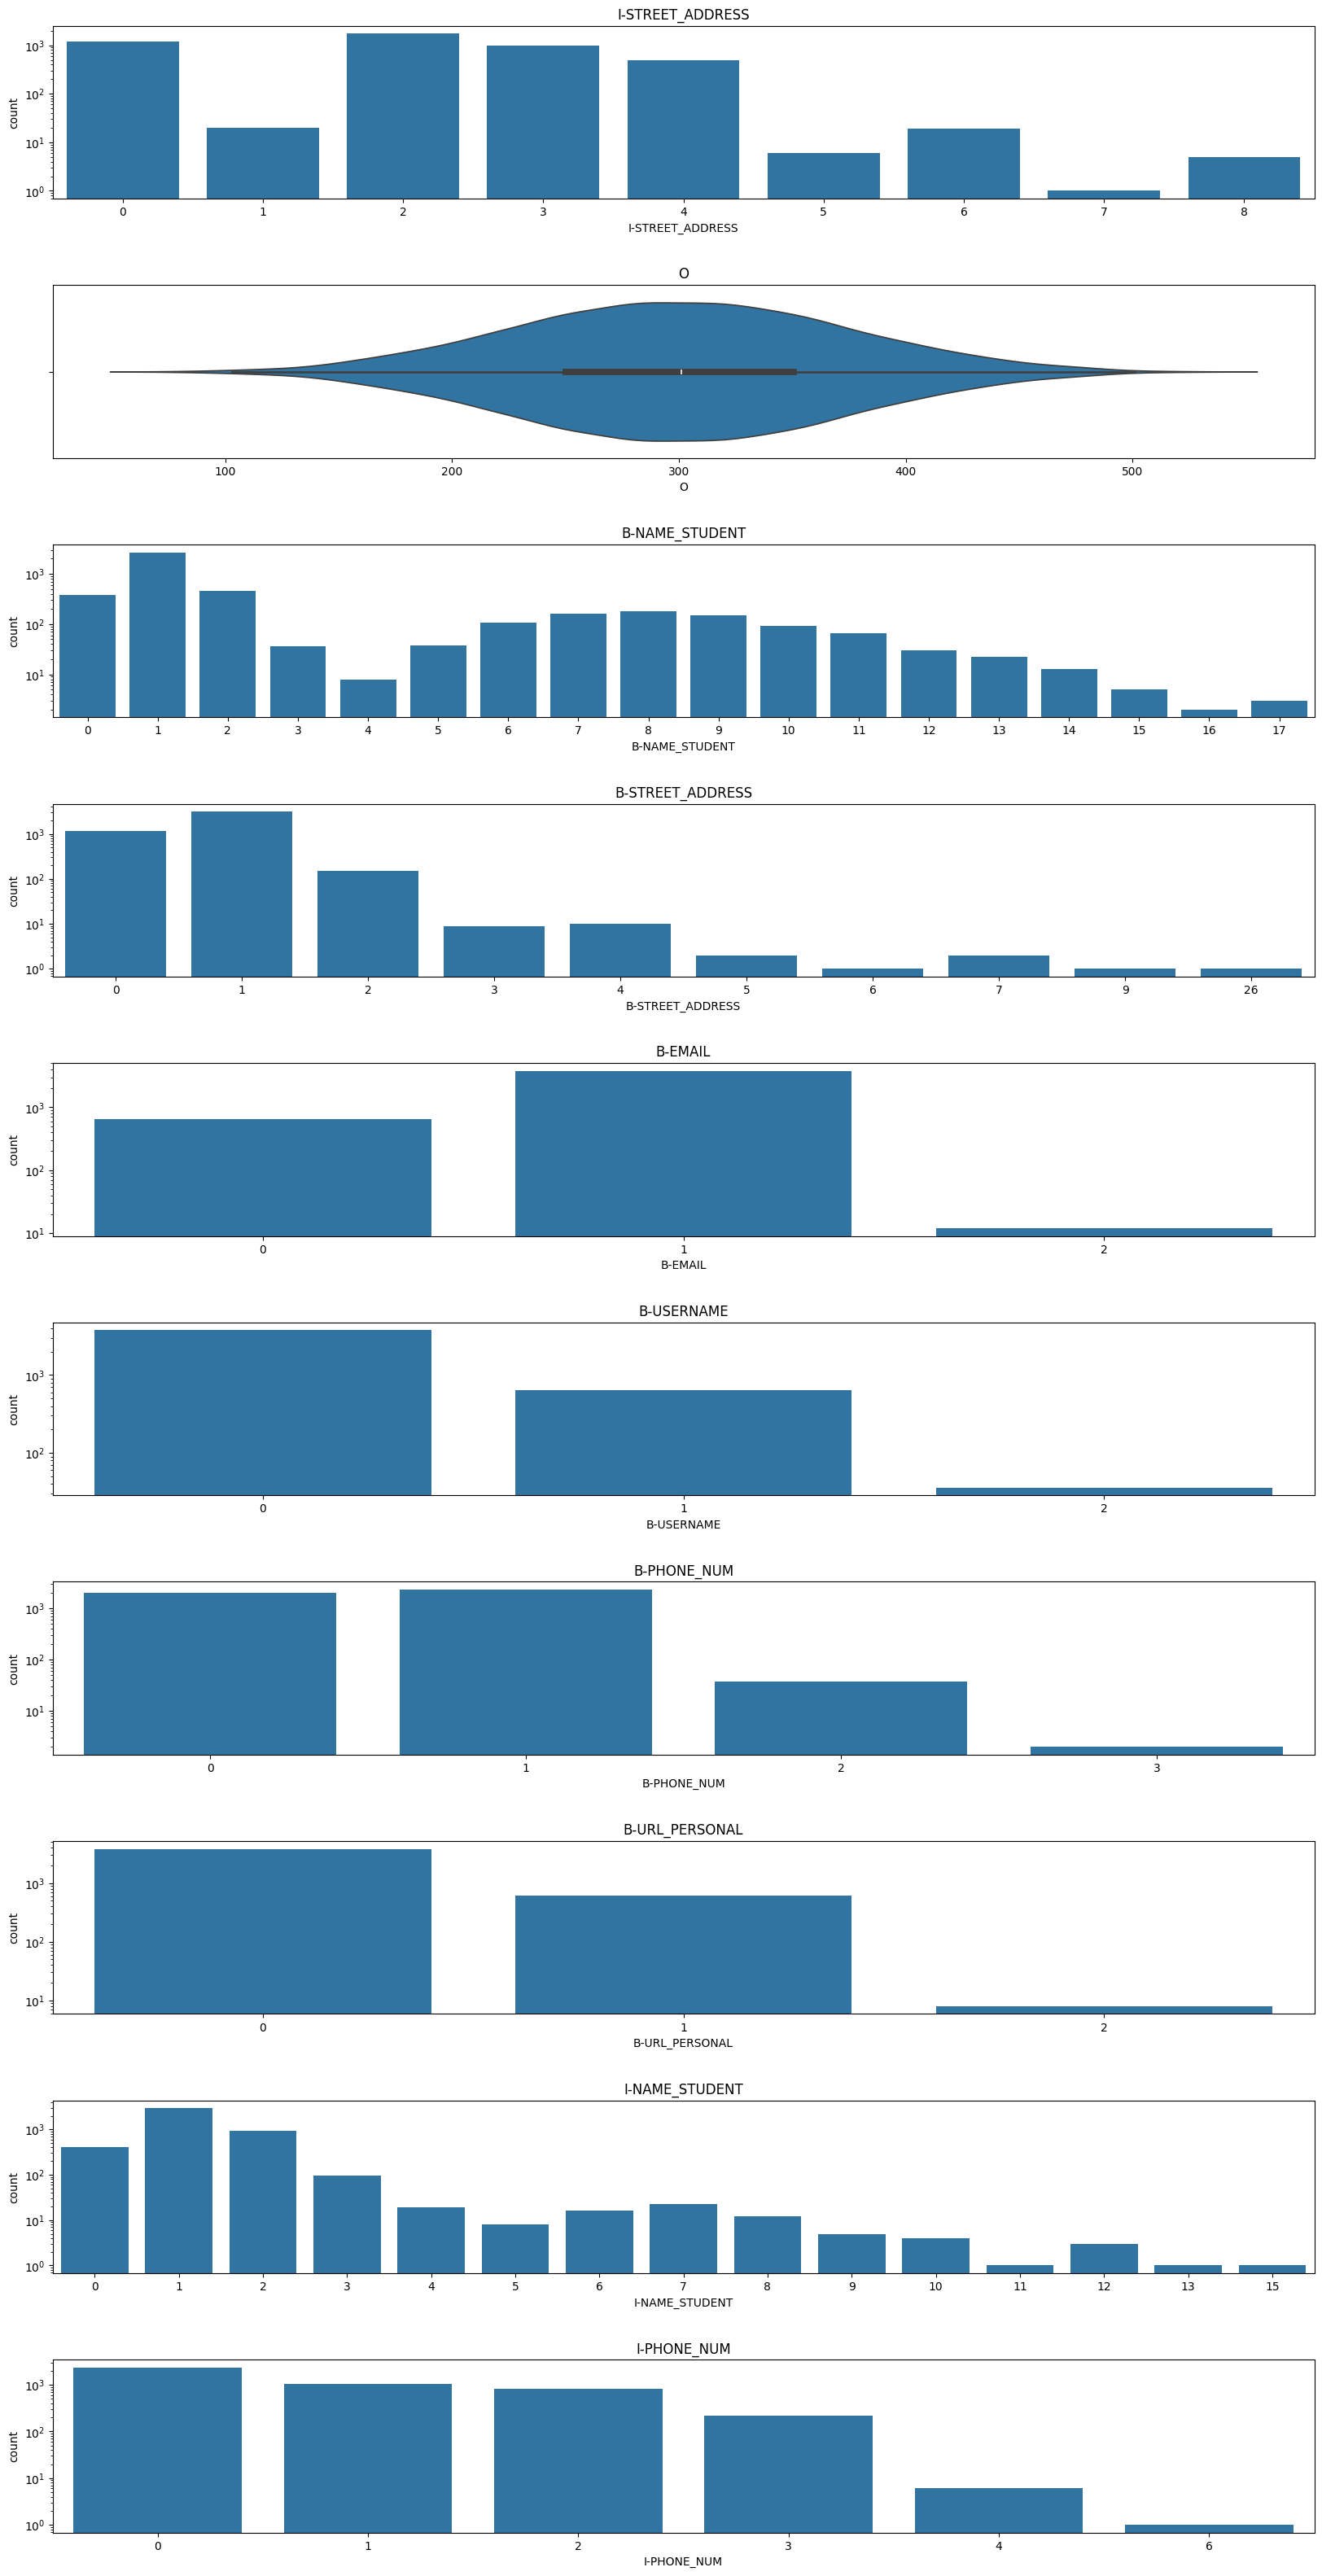

In [19]:
fig, axes = plt.subplots(nrows = len(uniq_labels), ncols = 1, figsize = (20, len(uniq_labels) * 4))
fig.subplots_adjust(hspace=0.5)

for uniq_label, ax in zip(uniq_labels, axes.flat):
    if uniq_label != 'O':
        sns.countplot(data = df_train, x = uniq_label, ax = ax)
        ax.set_yscale('log')
    else:
        sns.violinplot(data = df_train, x = uniq_label, ax = ax)
    ax.set_title(uniq_label)
    
plt.show()

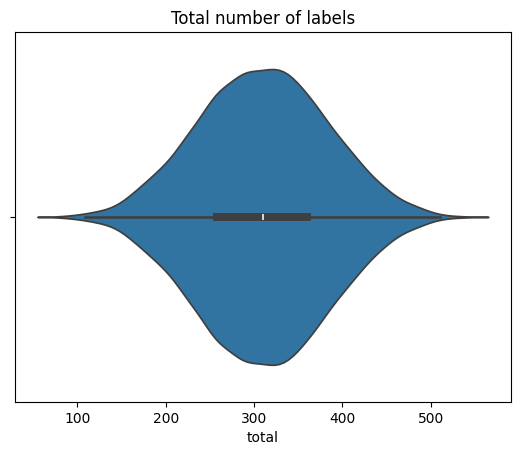

In [20]:
ax = sns.violinplot(data = df_train, x = "total")
ax.set_title("Total number of labels")
plt.show()

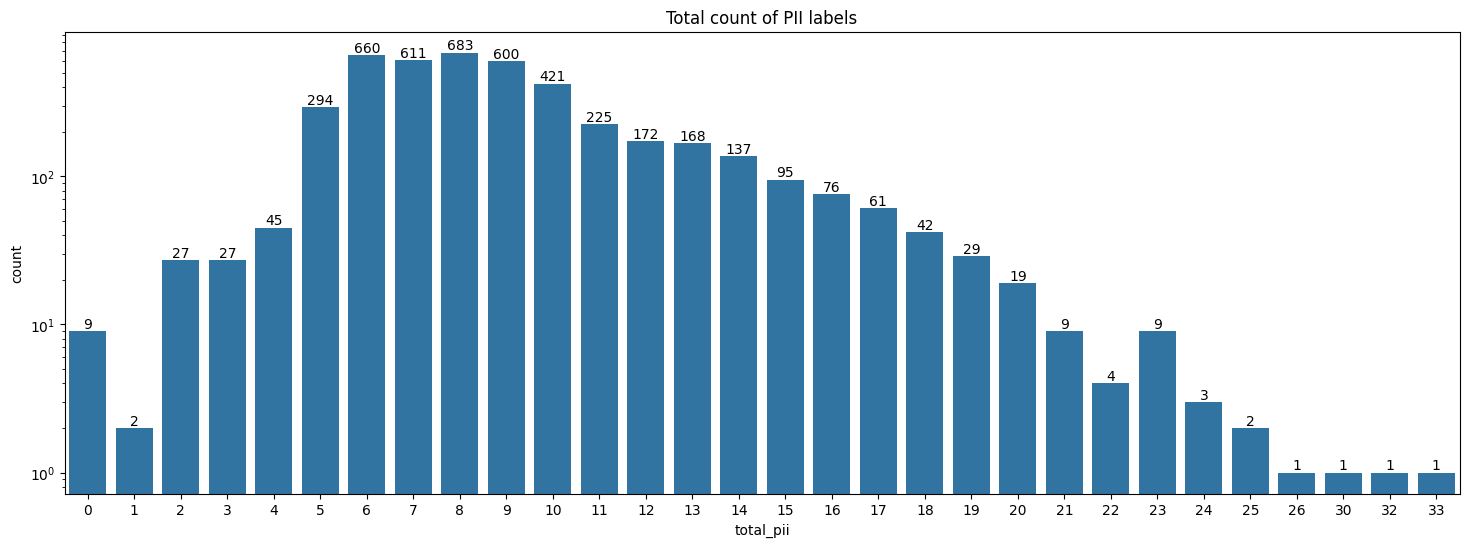

In [21]:
plt.figure(figsize=(18, 6))
ax = sns.countplot(data = df_train, x = "total_pii")
ax.set_title("Total count of PII labels")
ax.bar_label(ax.containers[0])
ax.set_yscale('log')

plt.show()

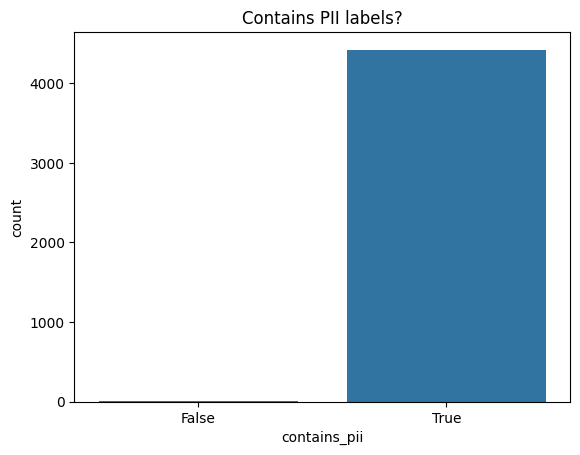

In [22]:
df_train["contains_pii"] = df_train["total_pii"] > 0

ax = sns.countplot(data = df_train, x = "contains_pii")
ax.set_title("Contains PII labels?")
plt.show()

Taking a Look At Essays Without PII

In [23]:
without_pii_example = df_train[~df_train["contains_pii"]].iloc[0]
without_pii_example

document                            0ade0268-3052-490a-af52-04deacb77ab3
full_text              In my role as a dermatologist with 4 years of ...
tokens                 [In, my, role, as, a, dermatologist, with, 4, ...
trailing_whitespace    [True, True, True, True, True, True, True, Tru...
labels                 [O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...
prompt                 \n    Ramesh Ma is a dermatologist with 4 year...
prompt_id                                                              1
name                                                           Ramesh Ma
email                                                ramesh.ma@yahoo.net
phone                                                       0542 2140259
job                                                        dermatologist
address                                                4493 Heath Circle
username                                                             NaN
url                                                

In [24]:
without_pii_example["full_text"]

"In my role as a dermatologist with 4 years of experience, I recently took on a project that involved developing a comprehensive treatment plan for a patient with a severe case of eczema. The patient, a 25-year-old woman named Sarah, had been struggling with the condition for several years and had tried various treatments with limited success. I started by conducting a thorough examination of Sarah's skin, taking note of the extent and severity of her eczema. I also asked her about her medical history, lifestyle, and any potential triggers that could be exacerbating her condition. Based on my findings, I diagnosed Sarah with atopic dermatitis, a type of eczema that is often associated with allergies and asthma. To address Sarah's eczema, I created a tailored treatment plan that included a combination of topical medications, lifestyle modifications, and stress management techniques. I prescribed a topical corticosteroid cream to help reduce inflammation and itching, as well as an emolli

In [25]:
def display_pii_tokens(ex):
    pii_records = []
    for idx, (token, label) in enumerate(zip(ex["tokens"], ex["labels"])):
        if label != 'O':
            pii_records.append({"idx": idx, "token": token, "label": label})
    return pd.DataFrame.from_records(pii_records)

In [26]:
display_pii_tokens(without_pii_example)

""


With PII

In [27]:
for uniq_label in uniq_labels:
    ex = df_train[df_train[uniq_label] > 0].iloc[0]
    pii_tokens = display_pii_tokens(ex)
    display(Markdown(f"## example for {uniq_label}"))
    display(Markdown(ex['full_text']))
    print()
    display(Markdown(f'### pii tokens'))
    print(pii_tokens)
    print()

## example for I-STREET_ADDRESS

### pii tokens

   idx                        token             label
0    3                      Aaliyah    B-NAME_STUDENT
1    4                      Popova,    I-NAME_STUDENT
2  276                         (95)       B-PHONE_NUM
3  277                   94215-7906       I-PHONE_NUM
4  282  aaliyah.popova4783@aol.edu.           B-EMAIL
5  360                           97  B-STREET_ADDRESS
6  361                      Lincoln  I-STREET_ADDRESS
7  362                      Street.  I-STREET_ADDRESS



## example for O

### pii tokens

...

### pii tokens

   idx                        token             label
0    3                      Aaliyah    B-NAME_STUDENT
1    4                      Popova,    I-NAME_STUDENT
2  276                         (95)       B-PHONE_NUM
3  277                   94215-7906       I-PHONE_NUM
4  282  aaliyah.popova4783@aol.edu.           B-EMAIL
5  360                           97  B-STREET_ADDRESS
6  361                      Lincoln  I-STREET_ADDRESS
7  362                      Street.  I-STREET_ADDRESS



## example for I-PHONE_NUM

### pii tokens

   idx                        token             label
0    3                      Aaliyah    B-NAME_STUDENT
1    4                      Popova,    I-NAME_STUDENT
2  276                         (95)       B-PHONE_NUM
3  277                   94215-7906       I-PHONE_NUM
4  282  aaliyah.popova4783@aol.edu.           B-EMAIL
5  360                           97  B-STREET_ADDRESS
6  361                      Lincoln  I-STREET_ADDRESS
7  362                      Street.  I-STREET_ADDRESS



Getting All Possible Tokens for Each Label

In [28]:
tokens = {uniq_label: [] for uniq_label in uniq_labels}
for idx, ex in df_train.iterrows():
    for token, label in zip(ex["tokens"], ex["labels"]):
        # we don't care about no pii examples
        if label != 'O':
            tokens[label].append(token)

In [ ]:
for uniq_label, l in tokens.items():
    display(Markdown(f"### All Instances of {uniq_label}"))
    print(l)
    print()
    
with open("tokens.json", "w") as file:
    json.dump(tokens, file)

### All Instances of I-STREET_ADDRESS

['Lincoln', 'Street.', 'Webster', 'Street.', 'Southwest', '71st', 'Terrace', 'Sicard', 'Street', 'Southeast.', 'North', '67th', 'Avenue.', 'Via', 'Baron,', 'Orchard', 'View', 'Road.', 'Summerview', 'Drive', 'Jericho', 'Street,', 'Jericho', 'Street', 'Martagon', 'Circle.', 'Ronnie', 'Track.', 'Ellis', 'Way', 'Iris', 'Way,', 'Tanglewood', 'Trail.', 'Amy', 'Pines', 'Suite', '960.', 'Crestview', 'Road', 'Keith', 'Street.', 'East', '56th', 'Avenue.', 'Westerly', 'Street,', 'Marsh', 'Haven', 'Lane.', 'Southeast', '37th', 'Street,', 'Water', 'Street.', 'Ramos', 'Lane.', 'Linda', 'Locks', 'Suite', '740,', 'Oleary', 'Drive.', 'Curtis', 'Road.', 'Central', 'Street.', 'Pearl', 'Street', 'Kim', 'Field', 'Fendall', 'Court.', 'The', 'Meadows,', 'North', 'Dawn', 'Drive.', 'Colonial', 'Road**', 'Newland', 'Street.', 'Rhodes', 'Parks', 'Suite', '200.', 'Pine', 'Street', 'Lowe', 'Parkway', 'Apt.', '293.', 'North', 'Main', 'Street.', 'West', 'Wedington', 'Drive', 'Cambridge', 'Street,', '6th', 'Street', 

### All Instances of O

[]



### All Instances of B-NAME_STUDENT

...

### All Instances of I-NAME_STUDENT

['Popova,', 'Becker,', 'Mitsubishi,', 'Mitsubishi', 'Sun,', 'Sun,', 'Hoffman,', 'Hoffman', 'Gross,', 'Tanaka,', 'Lopez', 'Lopez', 'Ma,', 'Yu,', 'Yu,', 'Volkova', 'Martin,', 'Martin', 'Martin', 'Martin', "Martin's", 'Martin', "Martin's", "Martin's", "Martin's", 'Martin', 'Luo,', "Luo's", 'Luo', 'Luo', "Luo's", 'Luo', "Luo's", 'Luo', 'Watanabe,', 'Weber,', 'Weber', 'Ma,', 'Martinez,', 'Ma,', 'Pan', 'Koch', 'McCallister,', 'Dong,', 'Sasaki,', 'Suzuki,', "Suzuki's", 'Weber,', 'Luo,', 'White.', 'Martinez,', 'Sasaki,', 'Kimura,', 'Moore,', 'Moore,', 'Tang,', 'Tang,', 'Jung,', 'Morozov', 'Inoue.', 'Jiang,', 'Matsumoto,', 'Watanabe,', 'Watanabe', 'Song,', 'Jung', 'Jung**', 'Kimura,', 'Dos', 'Santos', 'Keller,', 'Keller', 'Zhu,', 'Tanaka,', 'Schmitt,', "Schmitt's", 'Volkova,', 'Sun', 'Peters,', 'Martinez,', 'Lambert,', 'Yamamoto,', 'Gauthier,', 'Peters', 'Tang,', 'Kozlov,', 'Hayashi,', 'Alvarez,', 'Pereira,', 'Fontaine', 'Fontaine', 'Wagner,', 'Ito,', 'Taylor,', 'Gonzalez,', 'Yu,', 'Chen,', 'Da

### All Instances of I-PHONE_NUM

['94215-7906', '4429797.', '2215930', '68', '670', '7513', '96894-7830.', '10746', '1491', '49', '207', '3764', '98824-5547', '98087.', '17610', '3742,', '350', '216', '96198-7145', '19144', '1648.', '463', '150', '257', '342', '704', '2983,', '19740', '2520', '16450', '8250', '887', '825.', '349-7914,', '98738-4976', '923-7737.', '76', '181', '5878', '7524235,', '11251', '2534.', '369', '4303.', '93047-6678', '97006-2284', '12479', '7916', '5624828.', '32', '160', '4356**', '530', '1581', '9620965', '49939,', '16495,', '5370877.', '232-2878', '34', '523', '9544', '106-4421', '383-4575', '617-3473', '14454', '4408,', '13115', '4183', '30', '725', '6174.', '12926', '5493', '95275-6007.', '98032-9635', '892', '142,', '94749', '30220', '755', '274', '880-7200.', '539-8160', '942-7236', '786-5359.', '36', '918', '6522.', '8721414,', '98', '312', '5852', '89034', '290-1236', '962', '747,', '506', '152', '12494', '7308', '92184-7267.', '11376', '8069', '889-9141,', '175', '438,', '93250-8539

: 